# Evaluation 7: Prompt 8 vs prompt 9

In [19]:
# Imports
import os, json, sys
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import numpy as np
import seaborn as sns

In [20]:
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from evaluation_tool import duration_t_s_box_plot, multi_histogram, multi_bar_graph, multi_bar_model_graph, semantic_box_plot, violin_plot

In [21]:
prompt = "prompt8"
prompt2 = "prompt9"
gt_id = "gtb.45af4a46-d258-4251-b734-d407602299bd"

In [22]:
# Paths
notebook_path = os.getcwd()
project_root = os.path.dirname(os.path.abspath(notebook_path))
data_dir = os.path.join(project_root, "data")
evaluations_dir = os.path.join(data_dir, "evaluations")
responses_dir = os.path.join(data_dir, "generated")
vocab_dir = os.path.join(data_dir, "vocab")
prompt_dir = os.path.join(evaluations_dir, prompt)
prompt_dir2 = os.path.join(evaluations_dir, prompt2)
db_path = os.path.join(data_dir, "DB.db")
gt_path = os.path.join(evaluations_dir, f"{gt_id}.json")

In [23]:
# SQL Alchemy session
engine = create_engine(f"sqlite:///{db_path}")
session_factory = sessionmaker(bind=engine)
session = session_factory()

In [24]:
# Evaluations Unique IDs
unique_ids_medium2 = [
    "g2m-7-9.4d9feeee-c979-4c5a-8779-21889b49d63b", #gemma2:9b
    "l3m-1-9.02ec842c-c539-4fb5-b4fe-29fa29c878ee", #llama3:8b
    "l31m-3-9.85830d48-11a6-4fc2-9fa6-b45fc9a80348", #llama3.1:8b
    "mm-9-9.d7180795-ae97-4e5e-87de-e3ce3b689c00", #mistral-nemo:12b
]

unique_ids_medium = [
    "g2m-7-8.2bfda31a-5a91-4127-86b0-764d900776d1", #gemma2:9b
    "l3m-1-8.c8c48325-828d-4d41-8fc9-4f0d3880b56a", #llama3:8b
    "l31m-3-8.a2192fb0-40a9-426a-9780-3ddcb70eddac", #llama3.1:8b
    "mm-9-8.a7c9bf93-a276-4d45-a15f-e02c39bd7a07", #mistral-nemo:12b
]

In [25]:
# gt_res
with open(gt_path, "r", encoding="utf-8") as file:
    gt_res = [json.load(file)]

In [26]:
def load_evaluations(unique_ids, prompt_dir):
    res = []
    for unique_id in unique_ids:
        file_path = os.path.join(prompt_dir, f"{unique_id}.json")
        with open(file_path, "r", encoding="utf-8") as file:
            res.append(json.load(file))
    return res

In [27]:
res1 = load_evaluations(unique_ids_medium, prompt_dir)
res2 = load_evaluations(unique_ids_medium2, prompt_dir2)

res = [item for pair in zip(res1, res2) for item in pair]

### Duration Metrics

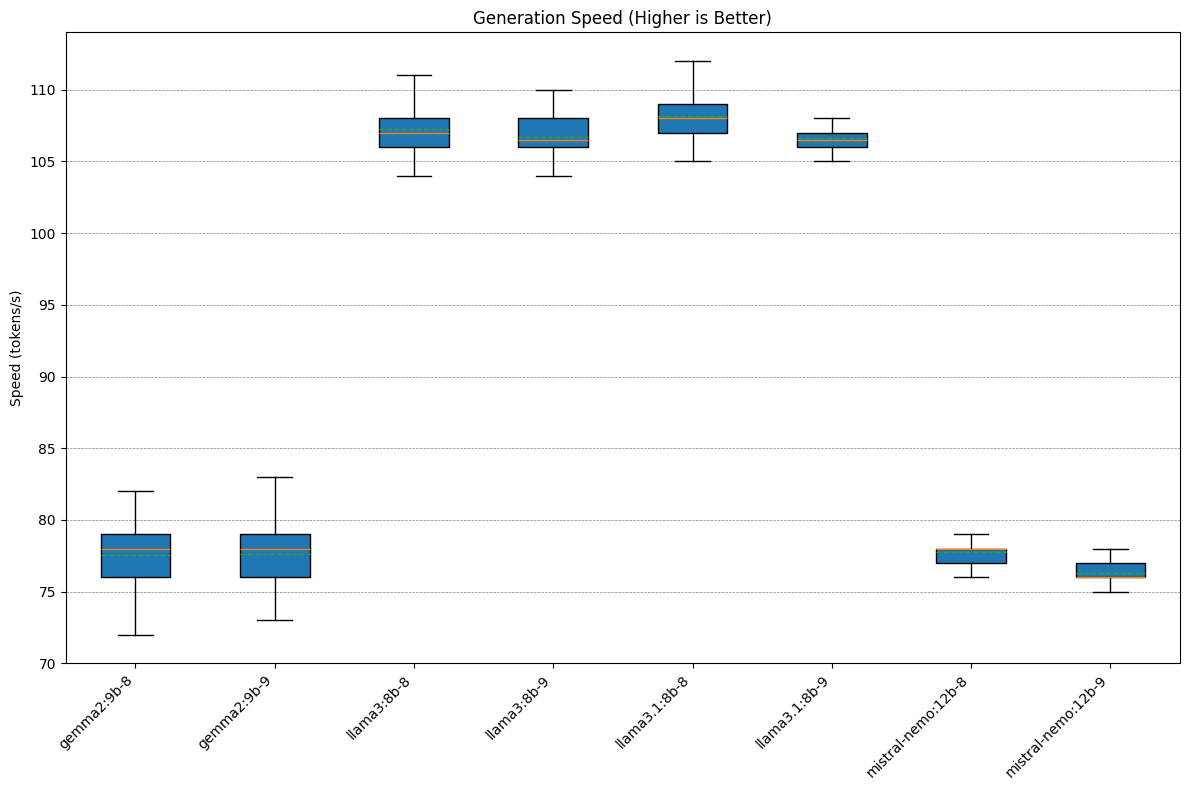

In [28]:
fig, ax = duration_t_s_box_plot(res)

### Difference Metrics

#### SM-Ratio

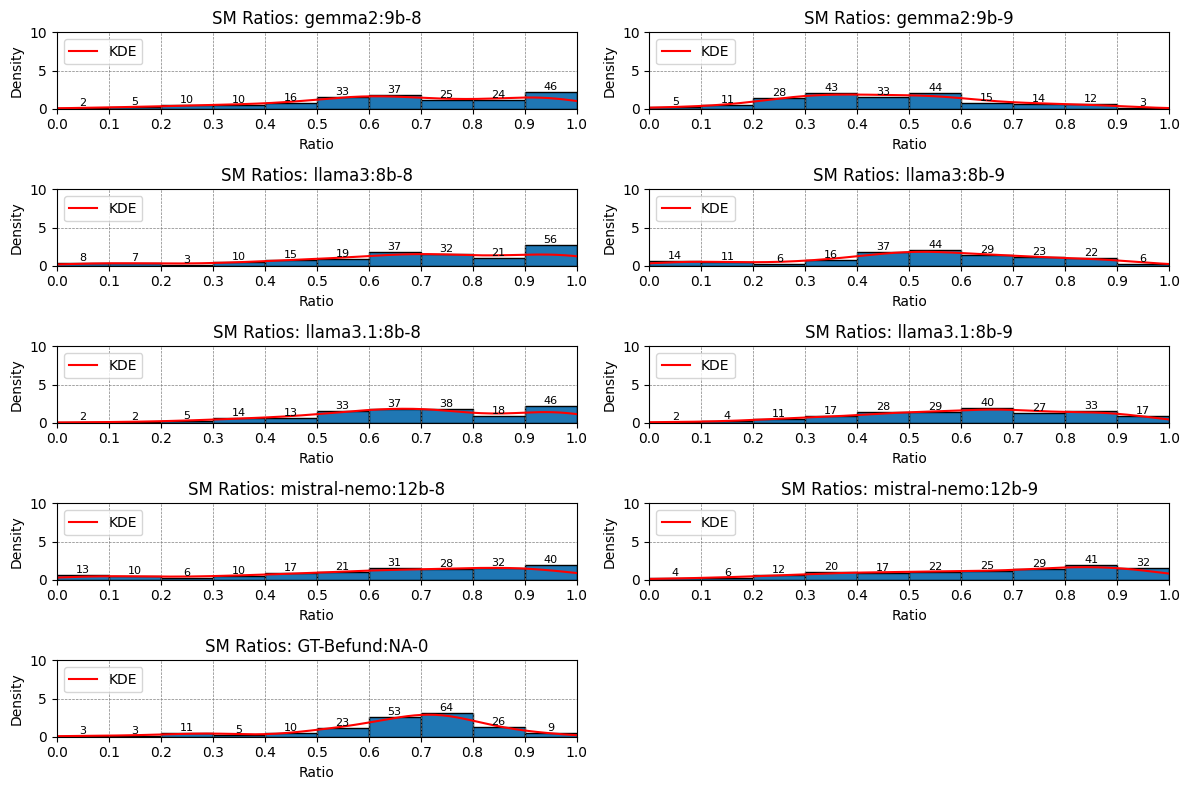

In [29]:
fig, ax = multi_histogram(res + gt_res, "sm_similarity_ratios", "SM Ratios", "upper left")

#### Levenshtein Distance Ratios

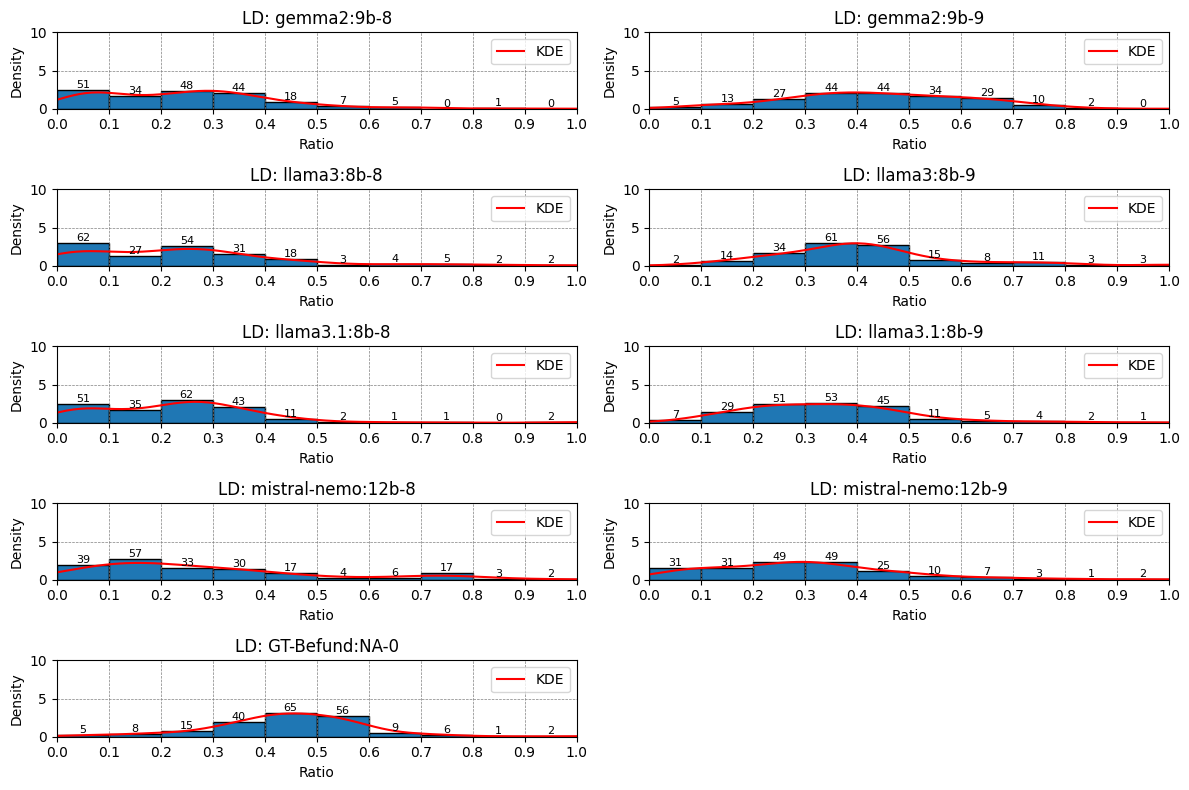

In [30]:
fig, ax = multi_histogram(res + gt_res, "levenshtein_distance_ratios", "LD", "upper right")

### LanguageTool Metrics

#### Spell Check

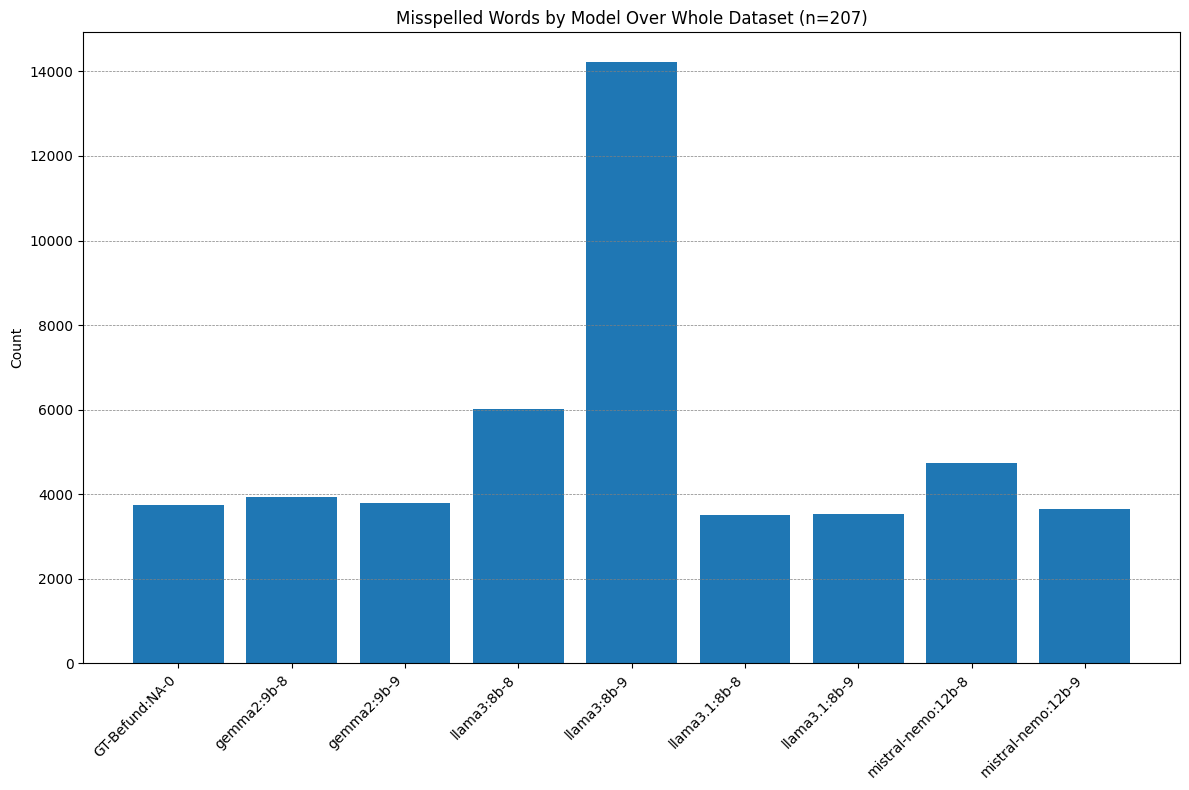

In [31]:
fig, ax = multi_bar_graph(gt_res + res, "misspelled", "Misspelled Words by Model Over Whole Dataset (n=207)")

#### Grammar Check

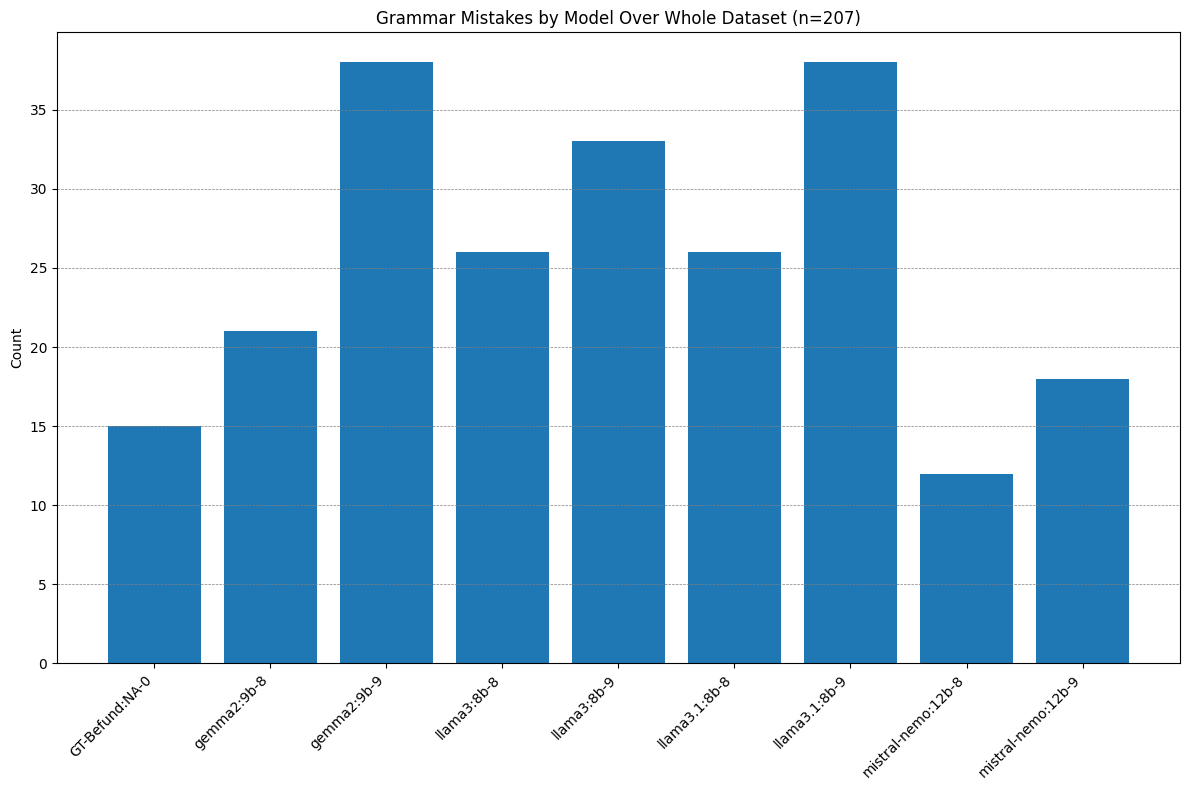

In [32]:
fig, ax = multi_bar_graph(gt_res + res, "grammer", "Grammar Mistakes by Model Over Whole Dataset (n=207)")

### Semantics Metrics

### Box plot

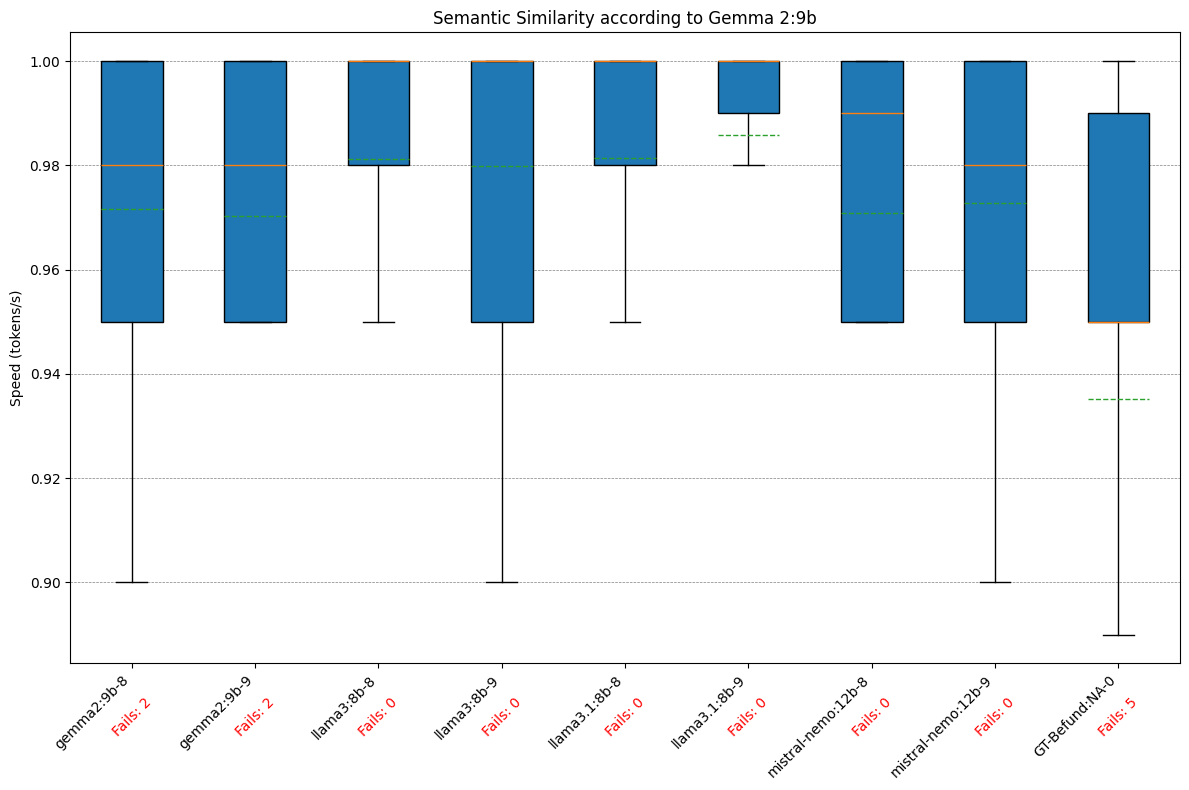

In [33]:
fig, ax = semantic_box_plot(res + gt_res)

### Violin Plot

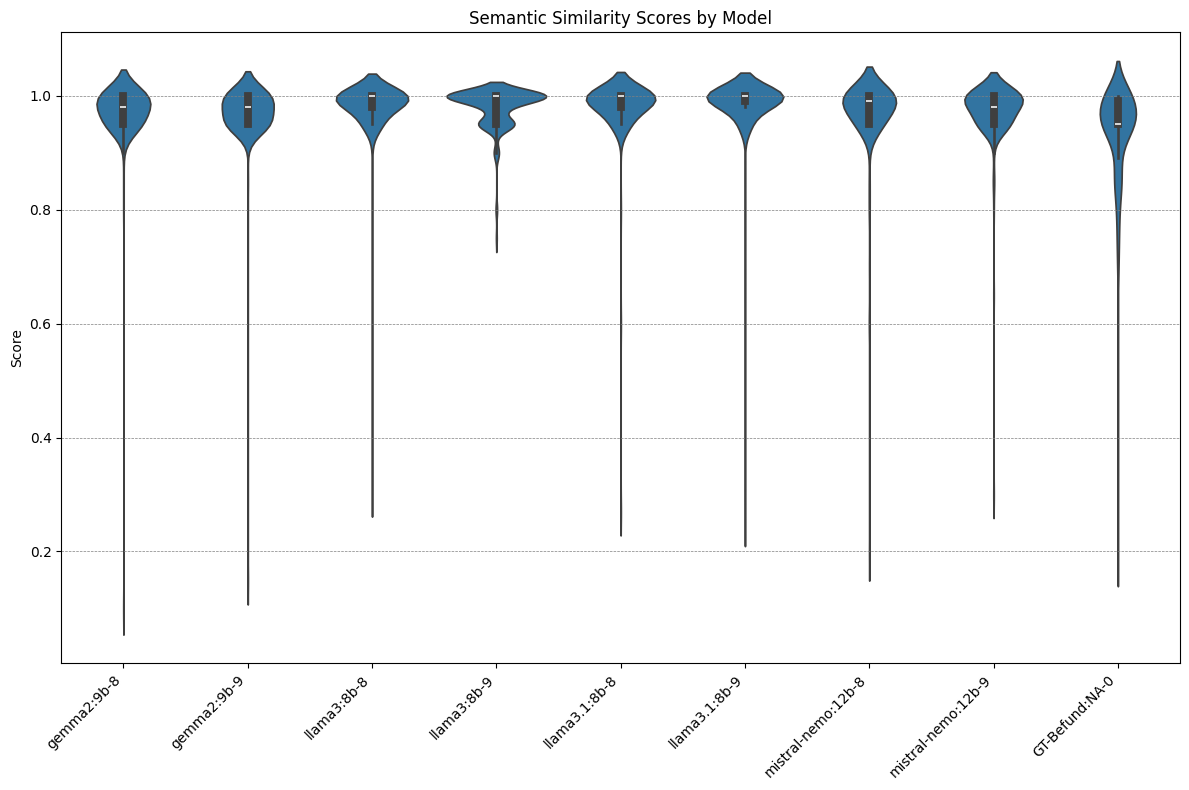

In [34]:
fig, ax = violin_plot(res + gt_res)

### Rating

In [35]:
def similarity_rating_graph(model_res1, model_res2, metric):
    "show a bar graph of the similarity ratings between two datasets"
    ratings1 = model_res1["metrics"]["semantic_metrics"][metric]
    ratings2 = model_res2["metrics"]["semantic_metrics"][metric]

    # Count the frequency of each rating (1 to 5)
    freq1 = [ratings1.count(i) for i in range(1, 6)]
    freq2 = [ratings2.count(i) for i in range(1, 6)]

    fig, ax = plt.subplots(figsize=(10, 5))

    indices = np.arange(1, 6)
    bar_width = 0.35

    # Plot the frequencies side by side
    bars1 = ax.bar(indices - bar_width/2, freq1, bar_width, color='skyblue', label=f'{model_res1["model"]["name"]}:{model_res1["model"]["size"]}-{model_res1["prompt"]["id"]}')
    bars2 = ax.bar(indices + bar_width/2, freq2, bar_width, color='lightgreen', label=f'{model_res2["model"]["name"]}:{model_res2["model"]["size"]}-{model_res2["prompt"]["id"]}')

    # Set the labels and title
    ax.set_title(f"Similarity Ratings for {metric}")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Frequency")
    ax.set_xticks(indices)
    ax.set_xticklabels(indices)

    ax.grid(True, color="gray", linestyle="--", linewidth=0.5, axis="y")
    ax.legend()

    fig.tight_layout()
    return fig, ax

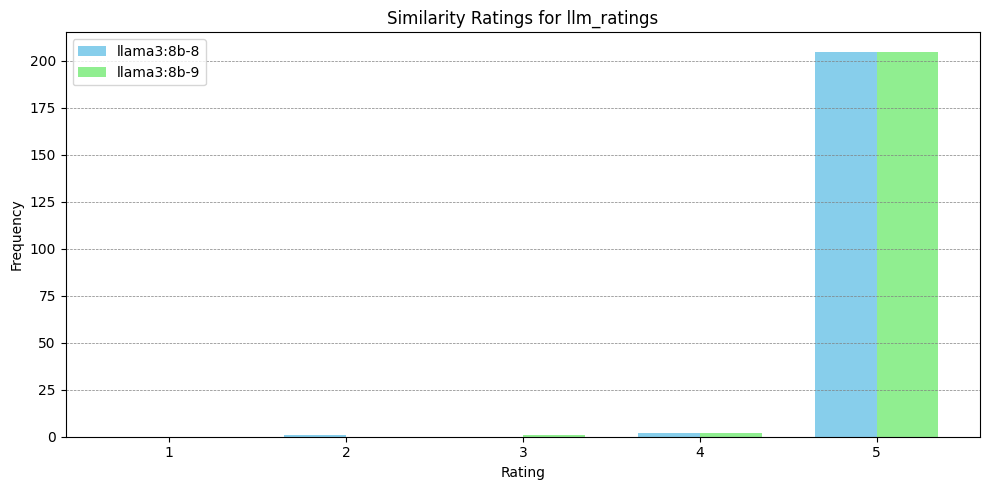

In [36]:
fig, ax = similarity_rating_graph(res1[1], res2[1], "llm_ratings")